In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.optimize import minimize, brentq
from scipy import stats
from scipy.stats import norm

# **I. Data Collection** - Barchart Data


We use Barchart website to retrieve call and put prices on SPX and VIX for 6 maturity pillars, and for liquid strikes.

Cf:  https://www.barchart.com/stocks/quotes/$SPX/options?expiration=2026-03-02-w&moneyness=50

## **A. SPX**

### 1. Retrieve Data

Extracted manualy via Barchart, and preformatting done in excel

#### **recomputing IV** 

In [10]:
def bs_call(S, K, r, q, sigma, T):
    """Black–Scholes European call with continuous dividend yield q."""
    vol_sqrt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / vol_sqrt
    d2 = d1 - vol_sqrt
    return S*np.exp(-q*T) * norm.cdf(d1) - K*np.exp(-r*T) * norm.cdf(d2)

def bs_put(S, K, r, q, sigma, T):
    """Black–Scholes European put with continuous dividend yield q."""
    vol_sqrt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / vol_sqrt
    d2 = d1 - vol_sqrt
    return K*np.exp(-r*T) * norm.cdf(-d2) - S*np.exp(-q*T) * norm.cdf(-d1)

def iv_one(S, K, T, r, q, market_price, opt_type):

    market_price = max(market_price, 1e-6)
    if opt_type.lower().startswith("c"):   # call
        lb = max(S - K*np.exp(-r*T), 0.0)
        ub = S
        price_fn = lambda sig: bs_call(S, K, r, q, sig, T)
    else:                                  # put
        lb = max(K*np.exp(-r*T) - S, 0.0)
        ub = K*np.exp(-r*T)
        price_fn = lambda sig: bs_put(S, K, r, q, sig, T)

    if (not np.isfinite(market_price)) or market_price <= 0:
        return np.nan
    if market_price < lb - 1e-10 or market_price > ub + 1e-10:
        return np.nan

    f = lambda sig: price_fn(sig) - market_price

    # robust bracket (expand if needed)
    a, b = 1e-8, 3.0
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        b = 10.0
        fb = f(b)
        if fa * fb > 0:
            return np.nan

    try:
        return brentq(f, a, b)
    except ValueError:
        return np.nan

### 2. Data Exploration

In [11]:
df_full = pd.read_excel('data/SPX_OPTIONS_asof_2026_02_24.xlsx')

S0 = df_full["UNDERLYING_LAST"].iloc[0]
dtes = df_full['DTE'].unique()
n = len(dtes)

df_full = df_full[df_full.VOLUME > 0 & (df_full.ASK > df_full.BID)]
df_full["T"] = df_full["DTE"] / 365
df_full["MONEYNESS"] = df_full["STRIKE"] / S0
df_full["LOG_MONEYNESS"] = np.log(df_full["MONEYNESS"])
df_full['REL_SPREAD'] = (0.5 * (df_full['ASK'] - df_full['BID'])/ df_full['MID'] ).clip(lower=1e-6)

#### Dataset IV

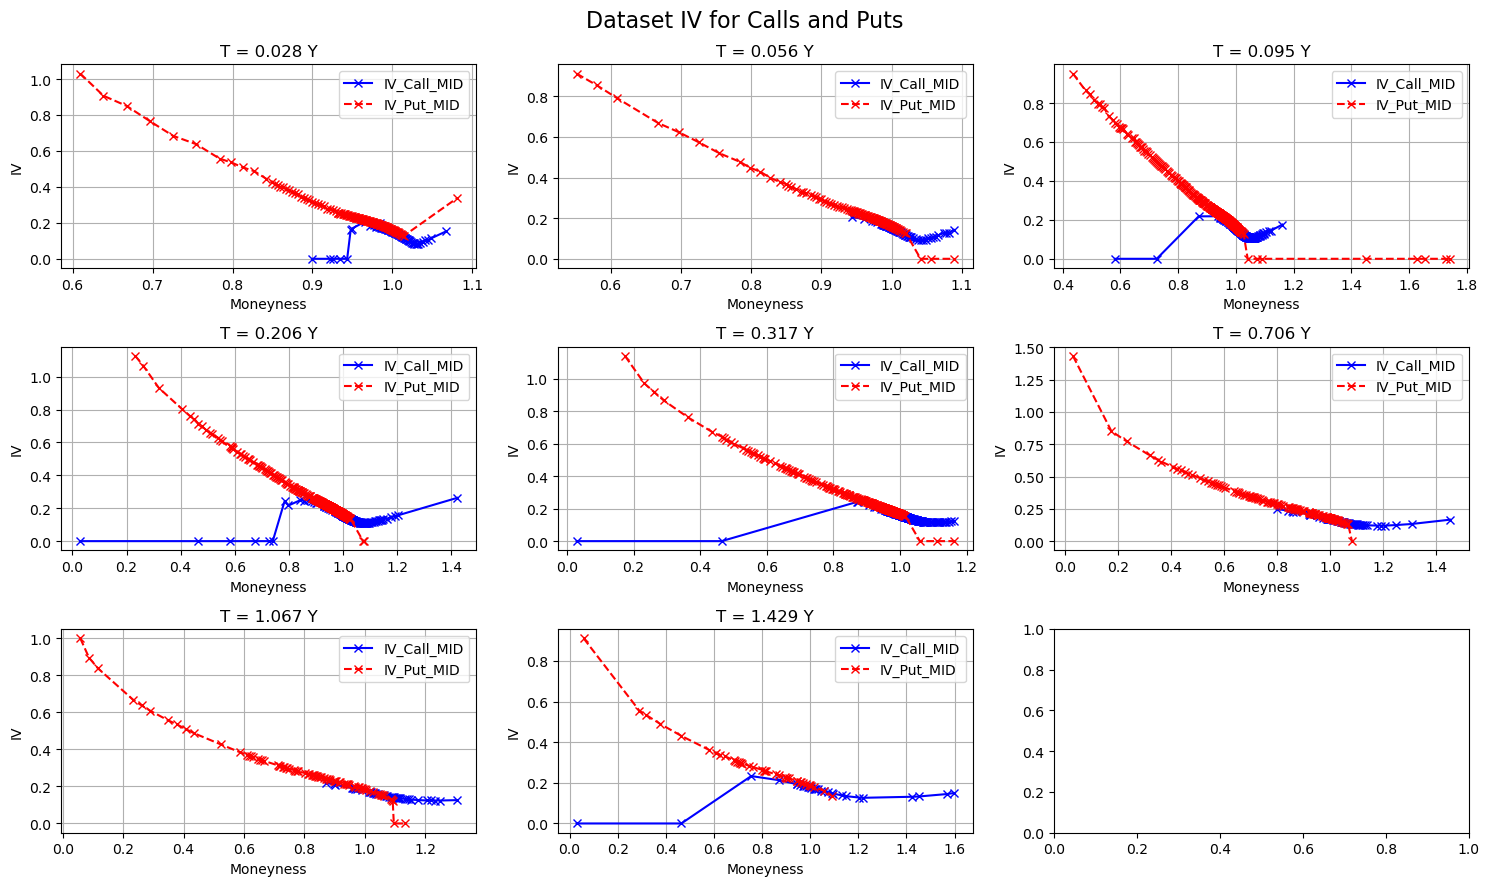

In [12]:
fig, axes = plt.subplots( nrows=3, ncols=3, figsize=(15, 3*3),)
axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data_call = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Call")].sort_values("STRIKE")
    data_put = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Put")].sort_values("STRIKE")


    ax.plot(data_call['MONEYNESS'], data_call['IV'], label='IV_Call_MID', color='blue', marker='x', linestyle="-")
    ax.plot(data_put['MONEYNESS'], data_put['IV'], label='IV_Put_MID', color='red', marker='x', linestyle="--")
    
    ax.set_title(f"T = {dte/252:.3f} Y")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("IV")
    ax.grid(True)
    ax.legend()

plt.suptitle('Dataset IV for Calls and Puts',fontsize=16)
plt.tight_layout()
plt.show()

#### Volume

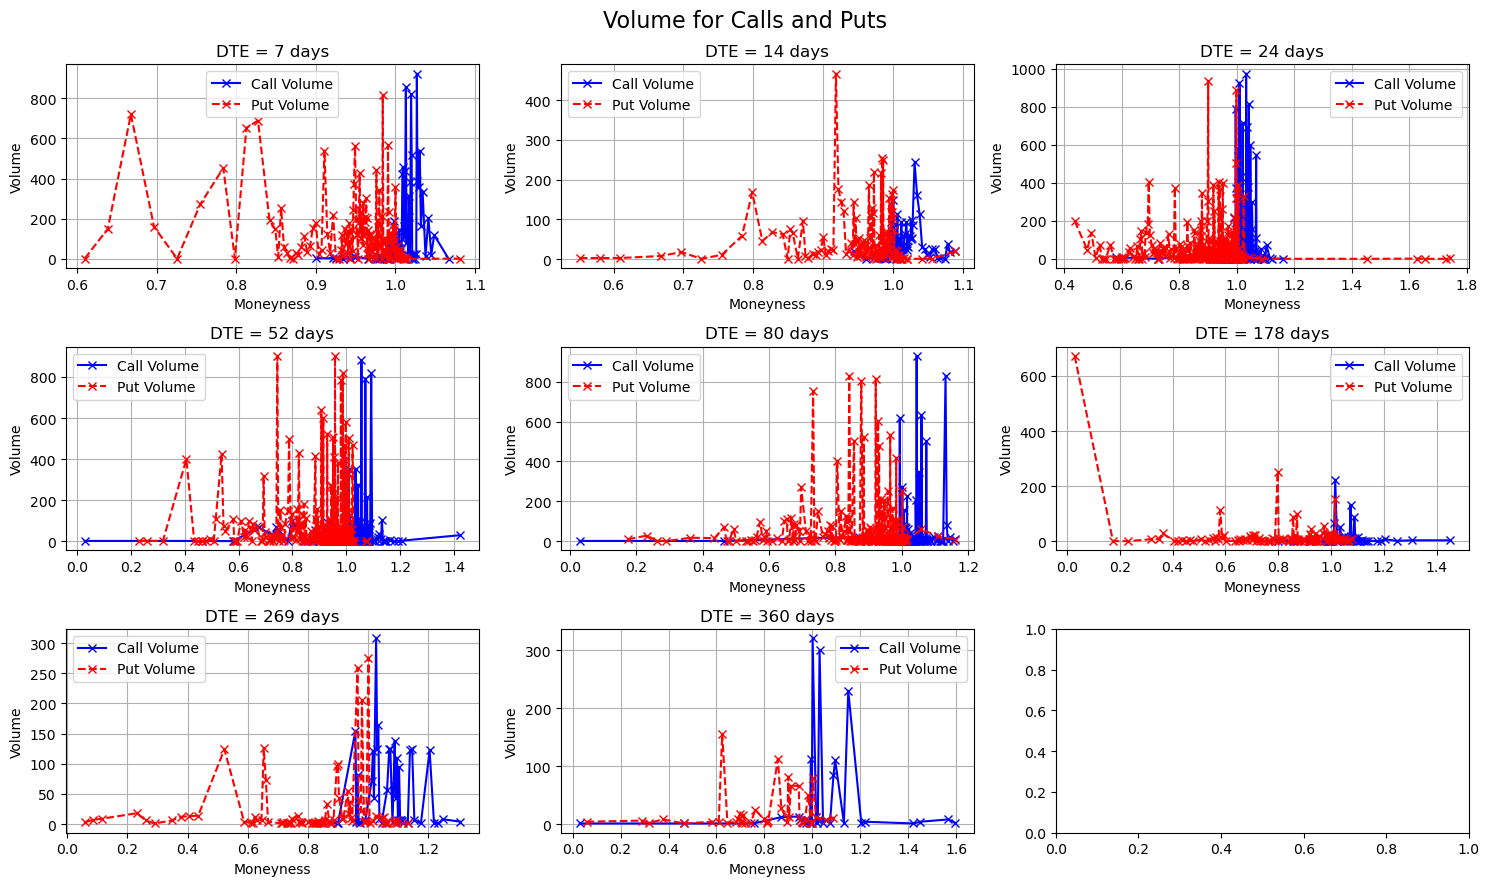

In [13]:
fig, axes = plt.subplots( nrows=3, ncols=3, figsize=(15, 3*3),)
axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data_call = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Call")].sort_values("STRIKE")
    data_put = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Put")].sort_values("STRIKE")


    ax.plot(data_call['MONEYNESS'], data_call['VOLUME'], label='Call Volume', color='blue', marker='x', linestyle="-")
    ax.plot(data_put['MONEYNESS'], data_put['VOLUME'], label='Put Volume', color='red', marker='x', linestyle="--")
    
    ax.set_title(f"DTE = {int(dte)} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Volume")
    ax.grid(True)
    ax.legend()

plt.suptitle('Volume for Calls and Puts',fontsize=16)
plt.tight_layout()
plt.show()

#### Relative Spread

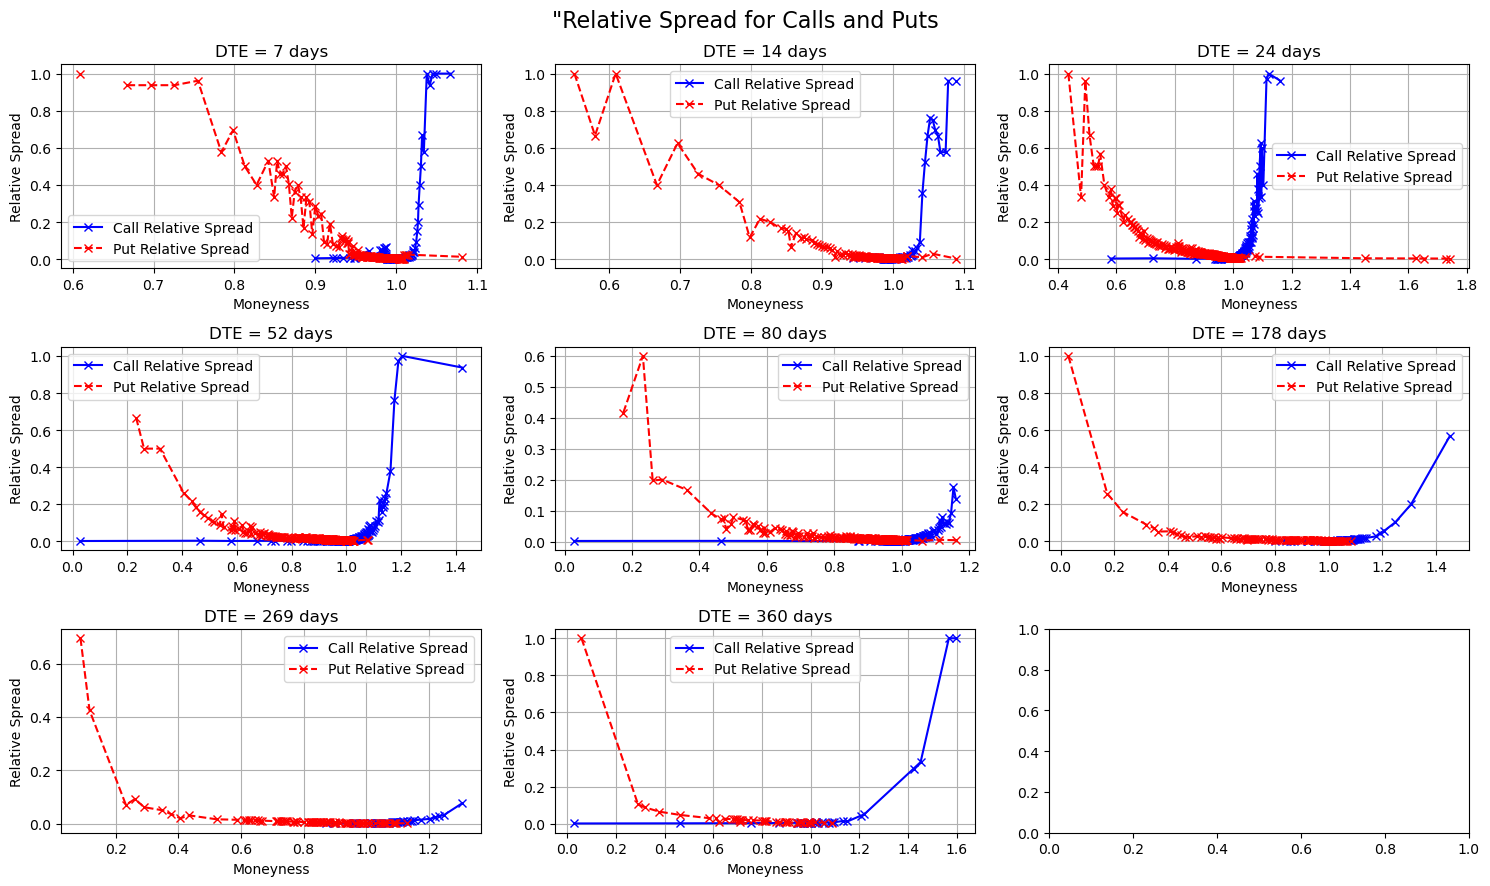

In [14]:
fig, axes = plt.subplots( nrows=3, ncols=3, figsize=(15, 3*3),)
axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data_call = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Call")].sort_values("STRIKE")
    data_put = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Put")].sort_values("STRIKE")


    ax.plot(data_call['MONEYNESS'], data_call['REL_SPREAD'], label='Call Relative Spread', color='blue', marker='x', linestyle="-")
    ax.plot(data_put['MONEYNESS'], data_put['REL_SPREAD'], label='Put Relative Spread', color='red', marker='x', linestyle="--")
    
    ax.set_title(f"DTE = {int(dte)} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Relative Spread")
    ax.grid(True)
    ax.legend()

plt.suptitle('"Relative Spread for Calls and Puts',fontsize=16)
plt.tight_layout()
plt.show()

#### Computed IV

In [15]:
r=0.036 # https://www.newyorkfed.org/markets/reference-rates/sofr
q=0.015 # https://www.multpl.com/s-p-500-dividend-yield/table/by-year

df_full["IV_MID"] = df_full.apply(
    lambda row: iv_one( S0, row["STRIKE"], row["T"], r, q, row["MID"], row["TYPE"],),axis=1)
df_full["IV_BID"] = df_full.apply(
    lambda row: iv_one( S0, row["STRIKE"], row["T"], r, q, row["BID"], row["TYPE"],),axis=1)
df_full["IV_ASK"] = df_full.apply(
    lambda row: iv_one( S0, row["STRIKE"], row["T"], r, q, row["ASK"], row["TYPE"],),axis=1)

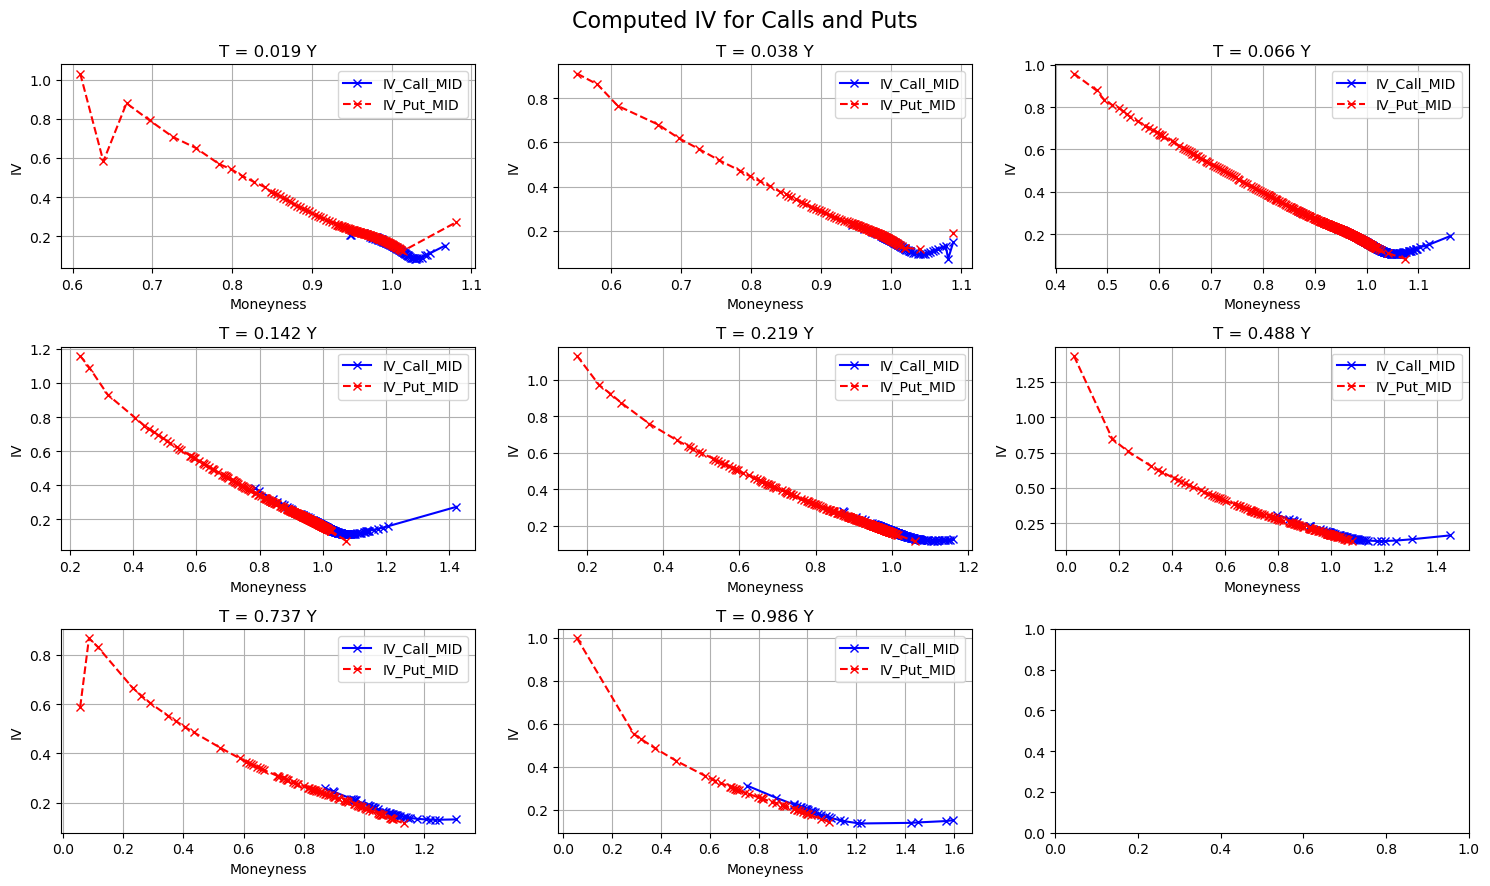

In [16]:
fig, axes = plt.subplots( nrows=3, ncols=3, figsize=(15, 3*3),)
axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data_call = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Call")].sort_values("STRIKE")
    data_put = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Put")].sort_values("STRIKE")


    ax.plot(data_call['MONEYNESS'], data_call['IV_MID'], label='IV_Call_MID', color='blue', marker='x', linestyle="-")
    ax.plot(data_put['MONEYNESS'], data_put['IV_MID'], label='IV_Put_MID', color='red', marker='x', linestyle="--")
    
    ax.set_title(f"T = {dte/365:.3f} Y")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("IV")
    ax.grid(True)
    ax.legend()

plt.suptitle('Computed IV for Calls and Puts',fontsize=16)
plt.tight_layout()
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

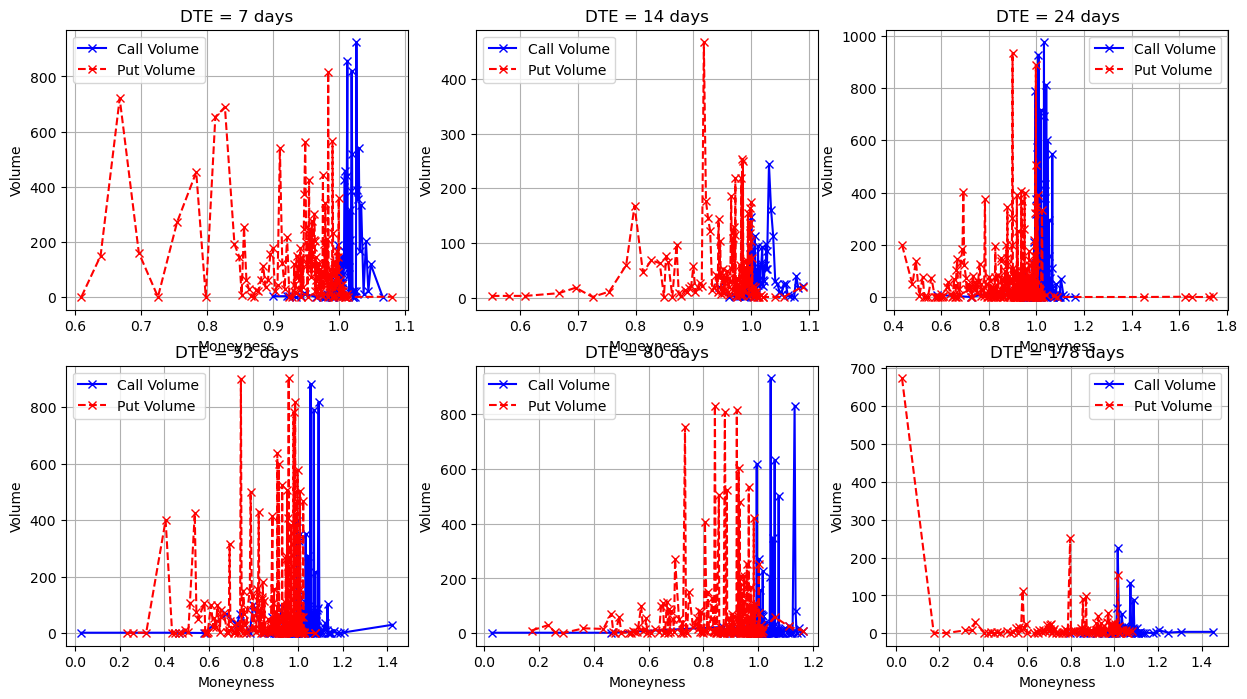

In [ ]:
n = len(dtes)

fig, axes = plt.subplots(
    nrows=2,   # 3 plots per row
    ncols=3,
    figsize=(15, 4 * 2),
)

axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data_call = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Call")].sort_values("STRIKE")
    data_put = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Put")].sort_values("STRIKE")


    ax.plot(data_call['MONEYNESS'], data_call['VOLUME'], label='Call Volume', color='blue', marker='x', linestyle="-")
    ax.plot(data_put['MONEYNESS'], data_put['VOLUME'], label='Put Volume', color='red', marker='x', linestyle="--")
    
    ax.set_title(f"DTE = {int(dte)} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Volume")
    ax.grid(True)
    ax.legend()

plt.suptitle('Volume for Calls and Puts',fontsize=16)
plt.tight_layout()
plt.show()

### 3. Processing Dataset to extract a proper IV

Taking calls OTM and puts OTM, observed in the dataset that puts were priced at a premium, tried to use volume weigting or spread weighting to prevent it, but not conclusive. -> use as imple before / after moneyness =1

#### Weights try (outdated)

In [7]:
p = 1.0      # p=1 or p=2 are common
eps = 1e-6   # numerical floor

g = df_full.copy()
g["W"] = 1.0 / g["REL_SPREAD"]

# pivot by strike/maturity
iv = g.pivot_table(index=["DTE","MONEYNESS"], columns="TYPE", values="IV", aggfunc="mean")
w  = g.pivot_table(index=["DTE","MONEYNESS"], columns="TYPE", values="W",  aggfunc="mean").fillna(0.0)

den = (w.get("Call", 0.0) + w.get("Put", 0.0)).replace(0, np.nan)
iv_star = (w.get("Call", 0.0)*iv.get("Call") + w.get("Put", 0.0)*iv.get("Put")) / den

df_star = iv_star.rename("IV_STAR").reset_index()

dte = 7
df_plot = df_star[df_star['DTE'] == dte]
data_call = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Call")].sort_values("STRIKE")
data_put = df_full[(df_full["DTE"] == dte) & (df_full["TYPE"] == "Put")].sort_values("STRIKE")

plt.figure(figsize=(6,4))
plt.plot(
    data_call["MONEYNESS"],
    data_call["IV"],
    marker="o",
)
plt.plot(
    data_put["MONEYNESS"],
    data_put["IV"],
    marker="x",
)

plt.plot(
    df_plot["MONEYNESS"],
    df_plot["IV_STAR"],
    marker="o",
)

plt.xlim(0.9,1.1)  
plt.ylim(0,0.6)  

NameError: name 'df_full' is not defined

#### Final choice

In [8]:
df = df_full.copy()
df = df[(df.VOLUME > 20) & (df.ASK > df.BID)]
df = df.dropna(subset = ['IV_ASK','IV_BID'])

df["KEEP"] = False
# keep OTM calls
df.loc[(df["TYPE"]=="Call") & (df["STRIKE"]>S0) , "KEEP"] = True
# keep OTM puts
df.loc[(df["TYPE"]=="Put")  & (df["STRIKE"]<S0) , "KEEP"] = True
df = df[df["KEEP"]]

print('Number of options:', df.shape[0])

NameError: name 'df_full' is not defined

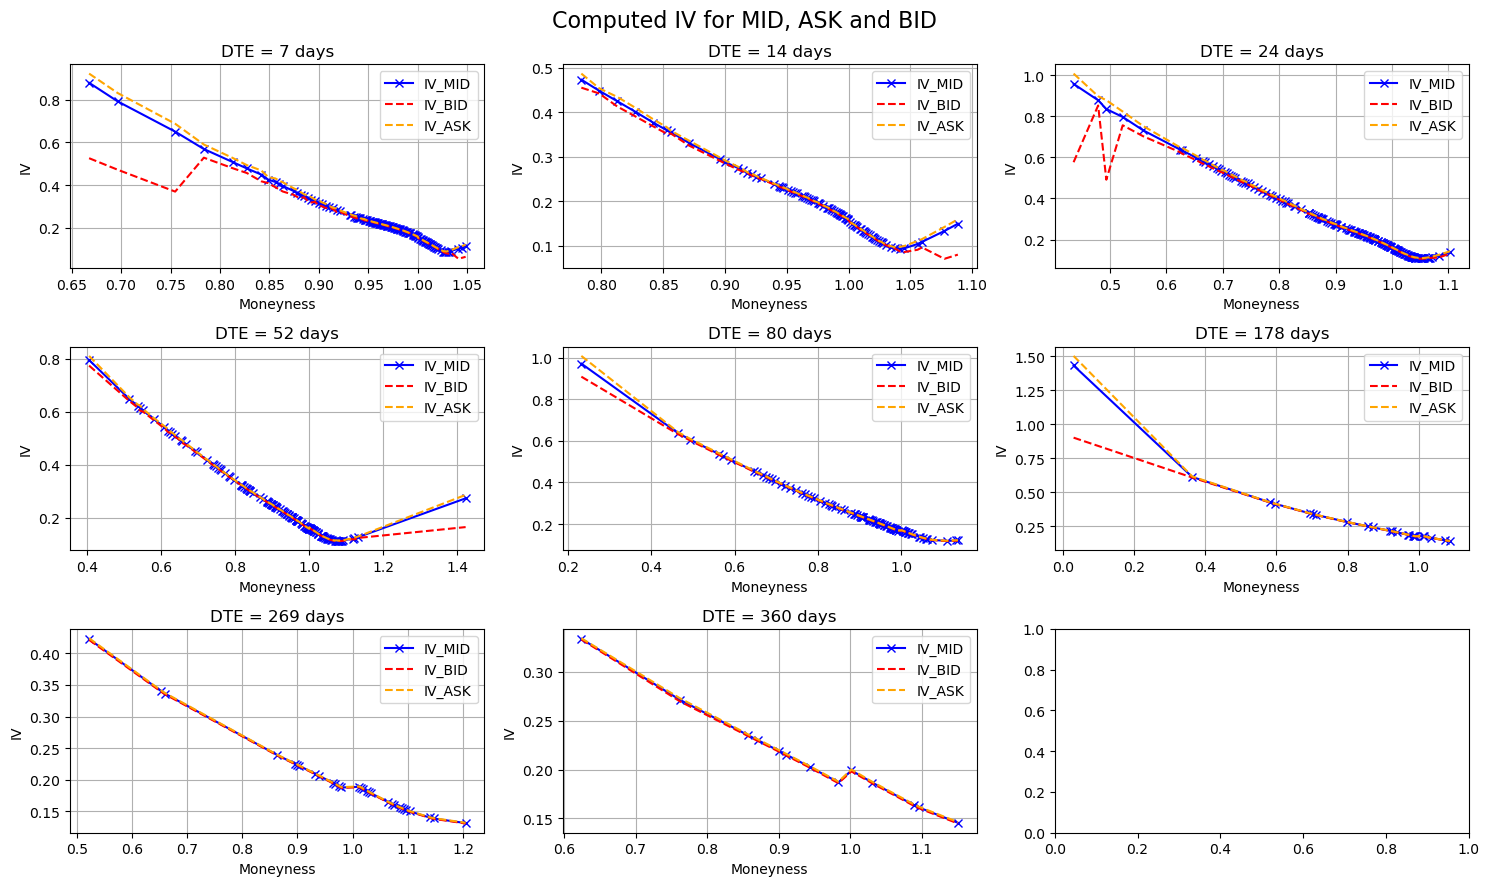

In [ ]:
fig, axes = plt.subplots( nrows=3, ncols=3, figsize=(15, 3*3),)
axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data = df[df["DTE"] == dte].sort_values("STRIKE")

    ax.plot(data['MONEYNESS'], data['IV_MID'], label='IV_MID', color='blue', marker='x', linestyle="-")
    ax.plot(data['MONEYNESS'], data['IV_BID'], label='IV_BID', color='red', marker='', linestyle="--")
    ax.plot(data['MONEYNESS'], data['IV_ASK'], label='IV_ASK', color='orange', marker='', linestyle="--")
    
    ax.set_title(f"DTE = {int(dte)} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("IV")
    ax.legend()
    ax.grid(True)

plt.suptitle('Computed IV for MID, ASK and BID',fontsize=16)
plt.tight_layout()
plt.show()

#### Less options

In [ ]:
df = df_full.copy()
df = df[(df.VOLUME > 20) & (df.ASK > df.BID)]
df = df.dropna(subset = ['IV_ASK','IV_BID'])

df["KEEP"] = False
# keep OTM calls
df.loc[(df["TYPE"]=="Call") & (df["STRIKE"]>S0) , "KEEP"] = True
# keep OTM puts
df.loc[(df["TYPE"]=="Put")  & (df["STRIKE"]<S0) , "KEEP"] = True
df = df[df["KEEP"]]

# Take top 20 volume per DTE
df = (
    df
    .sort_values(["DTE", "VOLUME"], ascending=[True, False])
    .groupby("DTE", group_keys=False)
    .head(30)
    .copy()
)

print('Number of options:', df.shape[0])

Number of options: 217


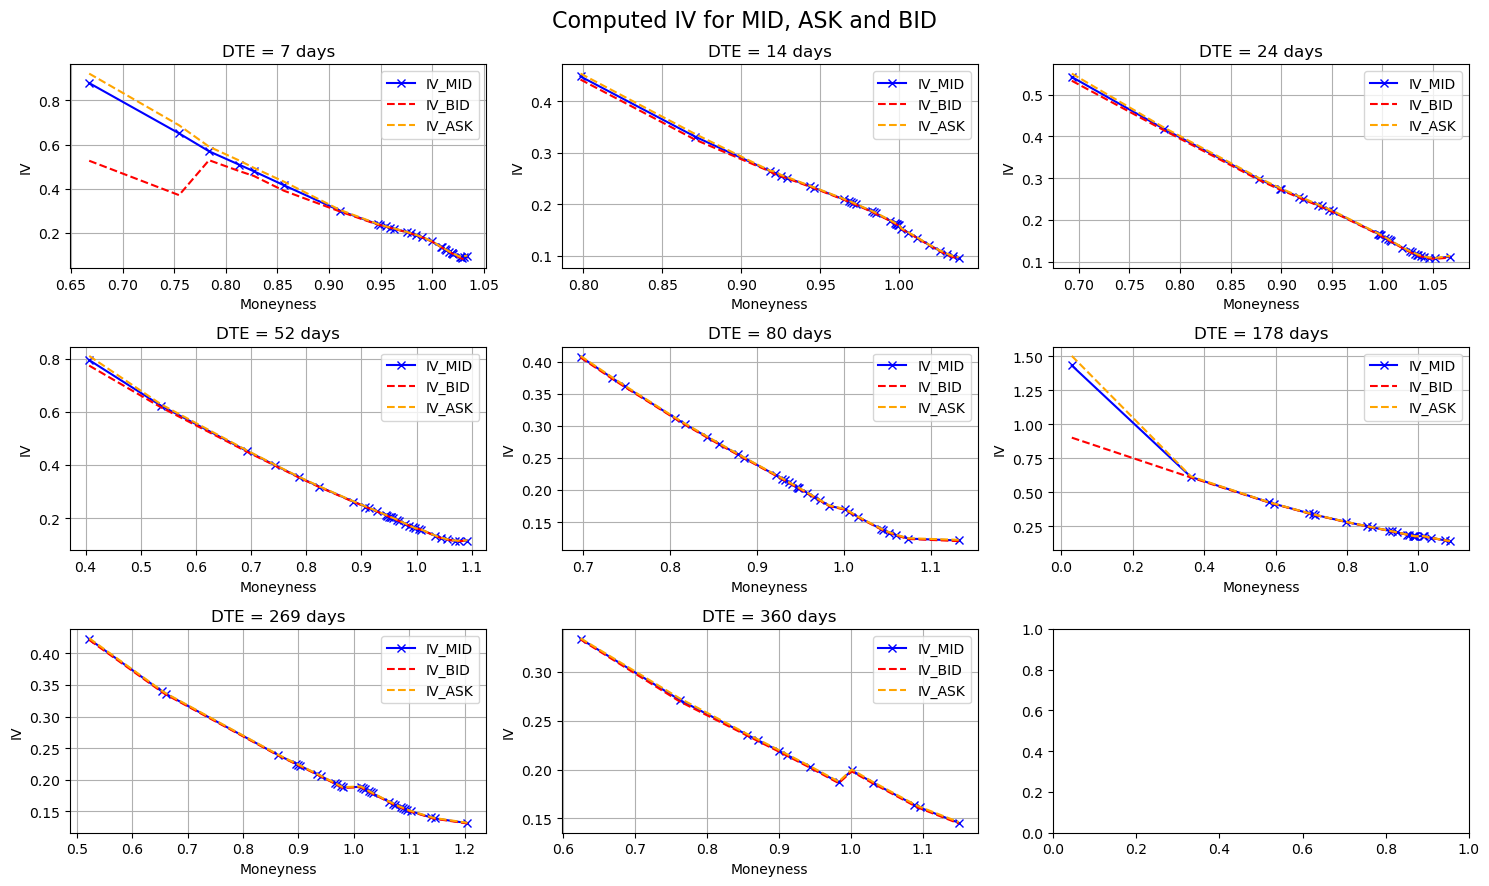

In [ ]:
fig, axes = plt.subplots( nrows=3, ncols=3, figsize=(15, 3*3),)
axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data = df[df["DTE"] == dte].sort_values("STRIKE")

    ax.plot(data['MONEYNESS'], data['IV_MID'], label='IV_MID', color='blue', marker='x', linestyle="-")
    ax.plot(data['MONEYNESS'], data['IV_BID'], label='IV_BID', color='red', marker='', linestyle="--")
    ax.plot(data['MONEYNESS'], data['IV_ASK'], label='IV_ASK', color='orange', marker='', linestyle="--")
    
    ax.set_title(f"DTE = {int(dte)} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("IV")
    ax.legend()
    ax.grid(True)

plt.suptitle('Computed IV for MID, ASK and BID',fontsize=16)
plt.tight_layout()
plt.show()


## **B. VIX**

# **II. Calibration** - Heston Model


## Part 1 - implement the characteristic function

$\large \varphi(X_0, K, v_0,\tau; \phi) = e^{r \phi i \tau} S^{i \phi}[\frac{1-ge^{d\tau}}{1-g}]^{\frac{-2a}{\sigma^2}} exp[\frac{a \tau}{\sigma^2} (b_2 -\rho\sigma \phi i + d) + \frac{v_0}{\sigma^2}(b_2 -\rho\sigma \phi i + d)[\frac{1-e^{d\tau}}{1-ge^{d\tau}}]]$

where d and g no longer change with b1, b2 or u1, u2
- $\large d = \sqrt{(\rho\sigma \phi i - b)^2 + \sigma^2 (\phi i + \phi^2)}$
- $\large g = \frac{b -\rho\sigma \phi i + d}{b -\rho\sigma \phi i - d}$
- $\large a = \kappa \theta$
- $\large b = \kappa + \lambda$

In [16]:
def heston_charfunc(phi, S0, v0, kappa, theta, sigma, rho, lambd, tau, r):

    # constants
    a = kappa*theta
    b = kappa+lambd

    # common terms w.r.t phi
    rspi = rho*sigma*phi*1j

    # define d parameter given phi and b
    d = np.sqrt( (rho*sigma*phi*1j - b)**2 + (phi*1j+phi**2)*sigma**2 )

    # define g parameter given phi, b and d
    g = (b-rspi+d)/(b-rspi-d)

    # calculate characteristic function by components
    exp1 = np.exp(r*phi*1j*tau)
    term2 = S0**(phi*1j) * ( (1-g*np.exp(d*tau))/(1-g) )**(-2*a/sigma**2)
    exp2 = np.exp(a*tau*(b-rspi+d)/sigma**2 + v0*(b-rspi+d)*( (1-np.exp(d*tau))/(1-g*np.exp(d*tau)) )/sigma**2)

    return exp1*term2*exp2

## Part 2 - define the integrand as a function

$\large \int^\inf_0 \Re [ e^{r\tau} \frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}} ] d\phi$

In [17]:
def integrand(phi, S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r):
    args = (S0, v0, kappa, theta, sigma, rho, lambd, tau, r)
    numerator = np.exp(r*tau)*heston_charfunc(phi-1j,*args) - K*heston_charfunc(phi,*args)
    denominator = 1j*phi*K**(1j*phi)
    return numerator/denominator

## Part 3 - perform numerical integration over integrand and calculate option price

$\large C(S_0, K, v_0, \tau) = \frac{1}{2}(S_0 - Ke^{-r \tau}) + \frac{1}{\pi} \int^\inf_0 \Re [ e^{r\tau} \frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}} ] d\phi$

### Using rectangular integration

In [77]:
#1st solution by using rectangular integration
def heston_price_rec(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r):
    args = (S0, v0, kappa, theta, sigma, rho, lambd, tau, r)

    P, umax, N = 0, 100, 10000
    dphi=umax/N #dphi is width

    for i in range(1,N):
        # rectangular integration
        phi = dphi * (2*i + 1)/2 # midpoint to calculate height
        numerator = np.exp(r*tau)*heston_charfunc(phi-1j,*args) - K * heston_charfunc(phi,*args)
        denominator = 1j*phi*K**(1j*phi)

        P += dphi * numerator/denominator

    return np.real((S0 - K*np.exp(-r*tau))/2 + P/np.pi)


#2nd solution : by using scipy quad integrate function
def heston_price(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r):
    args = (S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r)

    real_integral, err = np.real( quad(integrand, 0, 100, args=args) )

    return (S0 - K*np.exp(-r*tau))/2 + real_integral/np.pi


def heston_iv_model(S0, K, tau, r, q, v0, kappa, theta, sigma, rho, lambd):
    """
    Returns model IVs (same shape as K) by:
      Heston price -> BS implied vol via iv_one
    """
    # 1) model prices from Heston (must accept arrays)
    P_model = heston_price_rec(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r)

    # 2) invert to IV row-by-row with your iv_one
    iv_model = np.array([
        iv_one(S0, float(kk), float(tt), r, q, float(pp), 'Call')
        for kk, tt, pp in zip(np.asarray(K), np.asarray(tau), np.asarray(P_model))
    ], dtype=float)

    return iv_model

## Part 4 - Calibrate the parameters with the real market prices

https://www.maths.univ-evry.fr/pages_perso/crepey/Finance/051111_mikh%20heston.pdf

$\Large \Theta = (v0, \kappa, \theta, \sigma, \rho, \lambda)$

Minimize squared error:



$\Large SqErr(\Theta) = \sum^N_{i=1}\sum^M_{j=1}w_{ij}(C_{MP}(X_i,\tau_j) - C_{SV}(S_\tau, X_i,\tau_j,r_j,\Theta))^2 + Penalty(\Theta, \Theta_0)$

- The penalty function may be e. g. the distance to the initial parameter $vectorPenalty(\Theta, \Theta_0) = ||\Theta − \Theta_0||^2$


## Calibration - Optimization Objective function

$\Large \hat{\Theta} = \underset{\Theta \in U_\Theta}{arg \ min} \ SqErr(\Theta)$

Here we assume that the  set of possible combinations of parameters $U_\Theta$ is compact and in the range for which a solution exists.

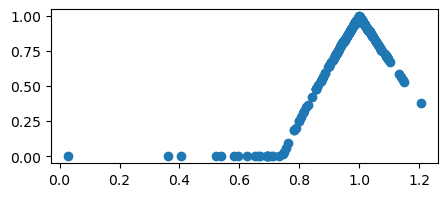

In [19]:
S0 = S0
r = 0.037

# Per-row maturity in years
tau = df["T"].astype(float).to_numpy()

# Per-row strike
K = df["STRIKE"].astype(float).to_numpy()

# Market implied vol target
iv_mkt = df["IV_MID"].astype(float).to_numpy()

m = df["MONEYNESS"].astype(float).to_numpy()

opt_type = df["TYPE"].to_numpy()

# ---- Weight only in a band around ATM (m ≈ 1) ----
# Use log-moneyness for symmetry
k = np.log(np.maximum(m, 1e-12))

band = 0.3 # tune (0.05–0.12 typical)
w = np.clip(1.0 - np.abs(k) / band, 0.0, 1.0)  # soft band
# hard band alternative:
# w = (np.abs(k) <= band).astype(float)

if w.sum() == 0:
    w[:] = 1.0

    
plt.figure(figsize=(5,2))
plt.scatter(m,w)
plt.show()

In [78]:
# ---- Start parameter guesses (robust defaults) ----
mask_atm = np.abs(k) < 0.02
iv_atm = np.median(iv_mkt[mask_atm]) if mask_atm.any() else np.median(iv_mkt)

V0 = max(iv_atm**2, 1e-4)

x0 = np.array([
    V0,     # v0
    2.0,    # kappa
    V0,     # theta
    0.6,    # sigma (vol of vol)
    -0.6,   # rho
    0.0     # lambd
], dtype=float)

bnds = [
    (1e-6, 0.5),     # v0
    (1e-3, 10.0),    # kappa
    (1e-6, 0.5),     # theta
    (1e-3, 5.0),     # sigma
    (-0.999, 0.0),   # rho (equity-style)
    (-5.0, 5.0),     # lambd
]

def SqErr(x): #TAKES W
    v0, kappa, theta, sigma, rho, lambd = x

    iv_model = heston_iv_model(S0, K, tau, r, q, v0, kappa, theta, sigma, rho, lambd)
    resid = iv_model - iv_mkt
    loss = np.sum(w * resid**2) / np.sum(w)
    return loss 

IndexError: boolean index did not match indexed array along axis 0; size of axis is 217 but size of corresponding boolean axis is 27

In [21]:
%%time 
iv_out = heston_iv_model(S0, K, tau, r, q, V0, kappa=2, theta=V0, sigma=0.6, rho=-0.6, lambd=0)
print('Time of 1 computation')

Time of 1 computation
CPU times: user 668 ms, sys: 4.85 ms, total: 672 ms
Wall time: 674 ms


In [22]:
%%time

res = minimize(
    SqErr,
    x0,
    method="SLSQP",
    bounds=bnds,
    tol=1e-3,
    options={"maxiter": 1000},
)

v0, kappa, theta, sigma, rho, lambd = res.x
print("Optimized params:", res.x)
print("Objective:", res.fun)

Optimized params: [ 0.02664706  2.          0.02664706  0.6        -0.6         0.        ]
Objective: nan
CPU times: user 5.06 s, sys: 42.8 ms, total: 5.1 s
Wall time: 5.15 s


## Part 5 - Calculate estimated option prices using calibrated parameters

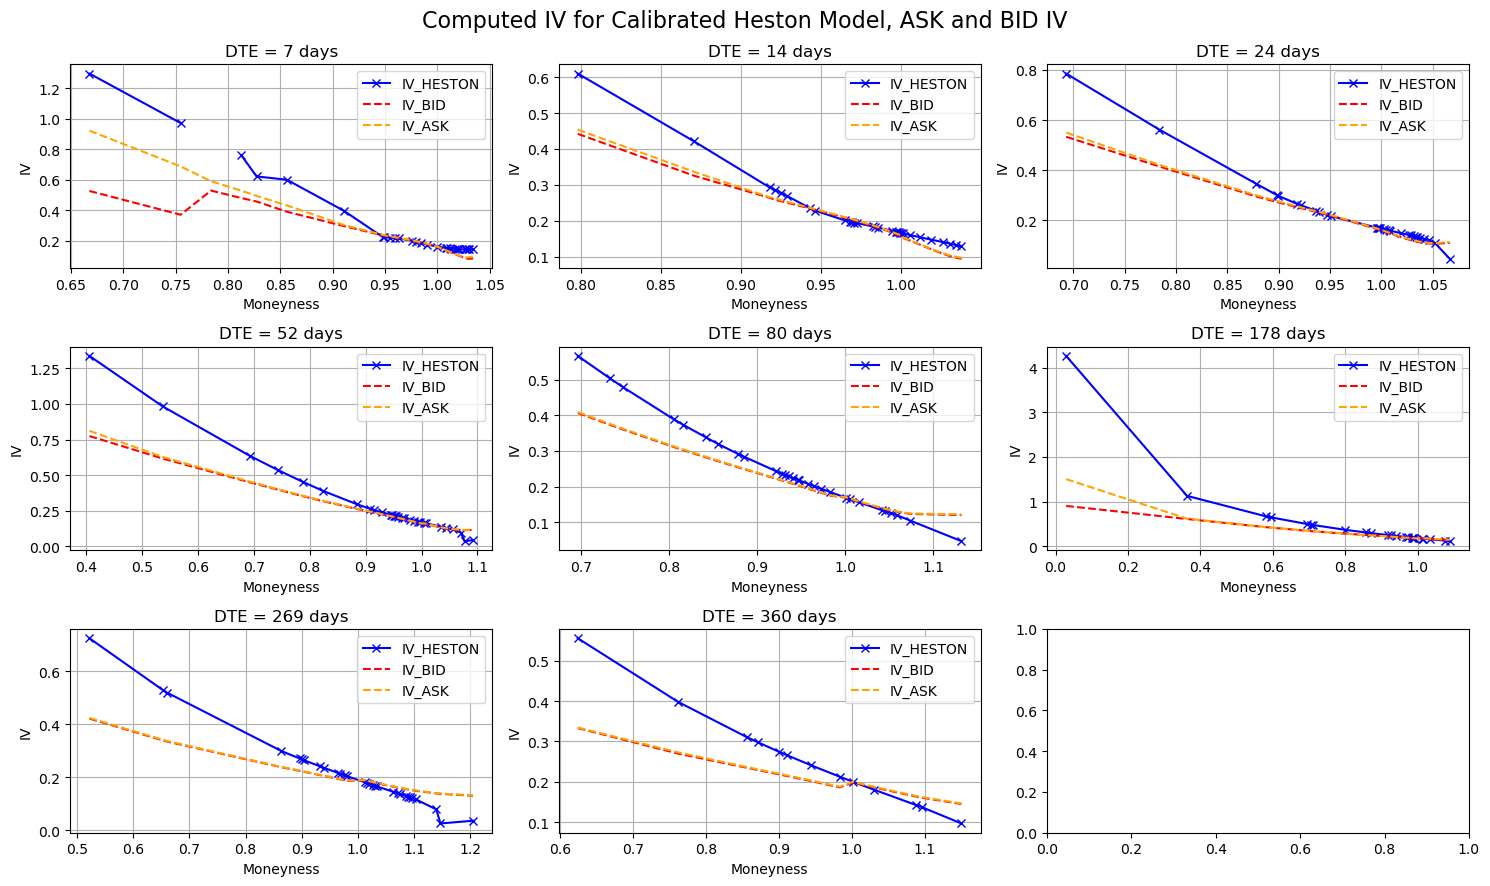

In [23]:
df['IV_HESTON'] = heston_iv_model(S0, K, tau, r, q , v0, kappa, theta, sigma, rho, lambd)

fig, axes = plt.subplots( nrows=3, ncols=3, figsize=(15, 3*3),)
axes = axes.flatten()

for i, dte in enumerate(dtes):
    ax = axes[i]
    data = df[df["DTE"] == dte].sort_values("STRIKE")

    ax.plot(data['MONEYNESS'], data['IV_HESTON'], label='IV_HESTON', color='blue', marker='x', linestyle="-")
    ax.plot(data['MONEYNESS'], data['IV_BID'], label='IV_BID', color='red', marker='', linestyle="--")
    ax.plot(data['MONEYNESS'], data['IV_ASK'], label='IV_ASK', color='orange', marker='', linestyle="--")
    
    ax.set_title(f"DTE = {int(dte)} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("IV")
    ax.legend()
    ax.grid(True)

plt.suptitle('Computed IV for Calibrated Heston Model, ASK and BID IV',fontsize=16)
plt.tight_layout()
plt.show()

# III Modelisation justification

## rBM

In [43]:
import numpy as np
import matplotlib.pyplot as plt


def fbm_cholesky(H, T=1.0, N=500, seed=None):
    """
    Simule un fractional Brownian motion via factorisation de Cholesky.

    Parameters
    ----------
    H : float
        Hurst exponent (0 < H < 1)
    T : float
        Horizon final
    N : int
        Nombre de points de discrétisation
    seed : int
        Graine aléatoire

    Returns
    -------
    t : array
        Grille temporelle
    B : array
        Trajectoire simulée
    """

    if seed is not None:
        np.random.seed(seed)

    t = np.linspace(0, T, N)
    dt = T / (N - 1)

    # Construction matrice de covariance
    cov = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            cov[i, j] = 0.5 * (
                t[i]**(2*H) +
                t[j]**(2*H) -
                np.abs(t[i] - t[j])**(2*H)
            )

    # Factorisation de Cholesky
    L = np.linalg.cholesky(cov + 1e-10*np.eye(N))

    # Bruit gaussien standard
    Z = np.random.randn(N)

    # Trajectoire fBM
    B = L @ Z

    return t, B

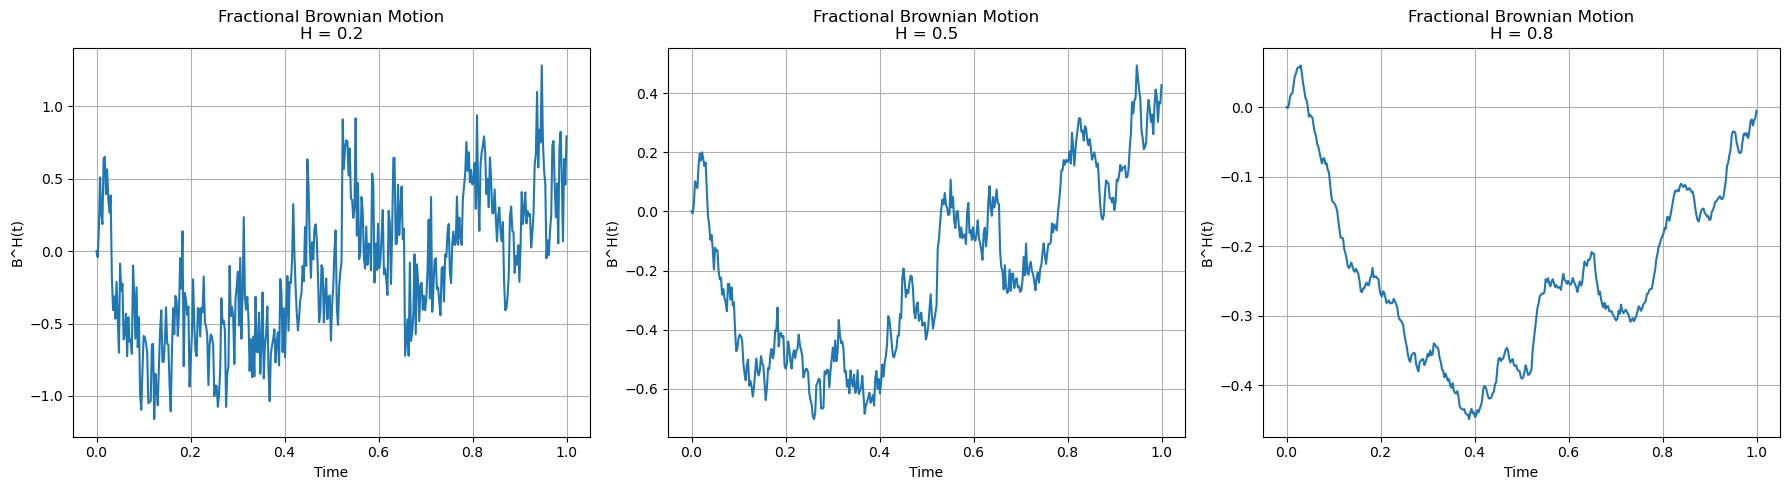

In [47]:
# H différents
Hs = [0.2, 0.5, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, H in zip(axes, Hs):
    t, B = fbm_cholesky(H, N=400, seed=42)
    ax.plot(t, B)
    ax.set_title(f"Fractional Brownian Motion\nH = {H}")
    ax.set_xlabel("Time")
    ax.set_ylabel("B^H(t)")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Regularity of the Log-Volatility

In [50]:
from scipy.stats import linregress

# Exemple : générer un fBM pour tester
H_true = 0.1
T = 1.0
N = 2000
t_grid = np.linspace(0, T, N)
_, B_H = fbm_cholesky(H_true, T=T, N=N, seed=42)

# Simuler "log-volatility" comme B^H
log_sigma = B_H.copy()  # log σ_t

# Paramètres d'analyse
q_list = [0.5, 1.0, 1.5, 2.0, 3.0]
max_lag = 100

# Stockage des moments
m_q_delta = {}

for q in q_list:
    m_q_delta[q] = []
    for delta in range(1, max_lag+1):
        increments = np.abs(log_sigma[delta:] - log_sigma[:-delta])**q
        m = np.mean(increments)
        m_q_delta[q].append(m)

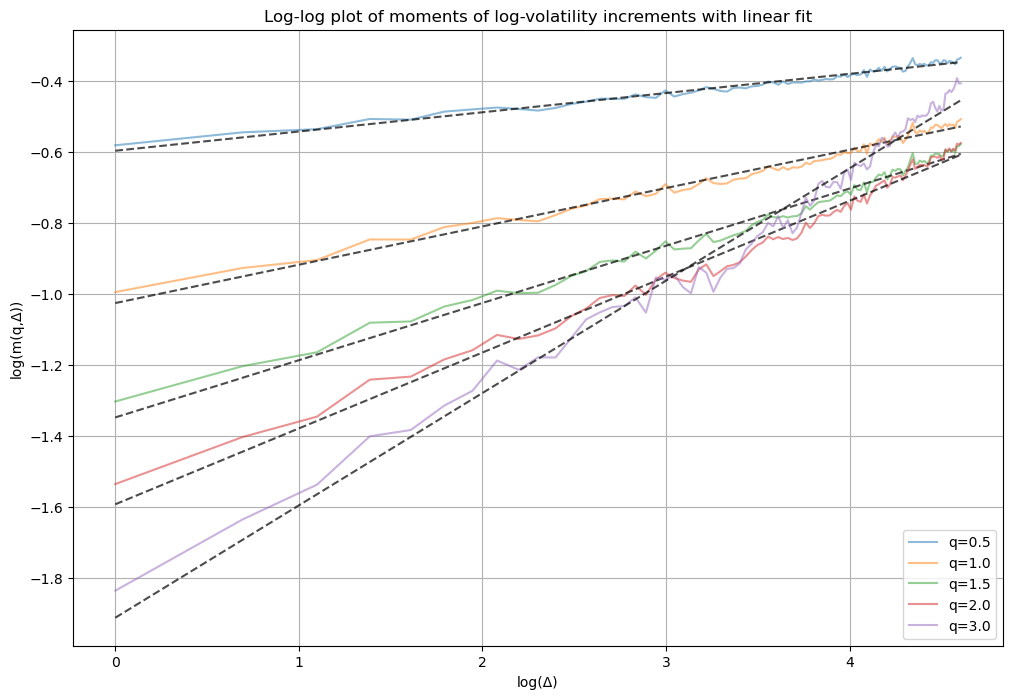

In [51]:
# ----------------------------
# Step 1: Fit log-log pour chaque q
# log(m(q,Δ)) ≈ ζ_q log(Δ) + C_q
# ----------------------------
zeta_q = []
plt.figure(figsize=(12,8))

for q in q_list:
    deltas = np.arange(1, max_lag+1)
    m_vals = np.array(m_q_delta[q])
    
    log_m = np.log(m_vals)
    log_delta = np.log(deltas)
    
    slope, intercept, r_value, p_value, std_err = linregress(log_delta, log_m)
    zeta_q.append(slope)
    
    # Plot log-log et fit
    plt.plot(log_delta, log_m, label=f"q={q}", alpha=0.5)
    plt.plot(log_delta, slope*log_delta + intercept, linestyle='--', color='black', alpha=0.7)

plt.xlabel("log(Δ)")
plt.ylabel("log(m(q,Δ))")
plt.title("Log-log plot of moments of log-volatility increments with linear fit")
plt.legend()
plt.grid(True)
plt.show()

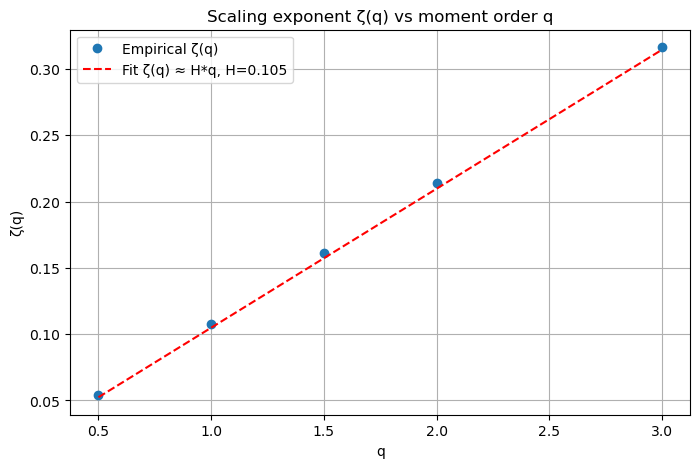

Estimated Hurst exponent H ≈ 0.105


In [52]:
#----------------------------
# Step 2: Fit ζ_q vs q
# ζ_q ≈ H*q
# ----------------------------
zeta_q = np.array(zeta_q)

slope, intercept, r_value, p_value, std_err = linregress(q_list, zeta_q)

plt.figure(figsize=(8,5))
plt.plot(q_list, zeta_q, 'o', label='Empirical ζ(q)')
plt.plot(q_list, slope*np.array(q_list), '--', color='red', label=f'Fit ζ(q) ≈ H*q, H={slope:.3f}')
plt.xlabel("q")
plt.ylabel("ζ(q)")
plt.title("Scaling exponent ζ(q) vs moment order q")
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated Hurst exponent H ≈ {slope:.3f}")

# IV Rough Heston

# OLD

In [ ]:
#import kagglehub

# Download latest version
# path = kagglehub.dataset_download("kylegraupe/spy-daily-eod-options-quotes-2020-2022")

#print("Path to dataset files:", path)

C:\Users\Massil\anaconda3_v2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|███████████████████████████████████████████████████████████████████████████████| 259M/259M [00:47<00:00, 5.67MB/s]

Extracting files...


Path to dataset files: C:\Users\Massil\.cache\kagglehub\datasets\kylegraupe\spy-daily-eod-options-quotes-2020-2022\versions\1


In [ ]:
# df = pd.read_csv('C:\\Users\\Massil\\.cache\\kagglehub\\datasets\\kylegraupe\\spy-daily-eod-options-quotes-2020-2022\\versions\\1\\spy_2020_2022.csv')

C:\Users\Massil\AppData\Local\Temp\ipykernel_12008\618949330.py:1: DtypeWarning: Columns (8,9,10,11,12,13,15,17,18,20,21,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\Massil\\.cache\\kagglehub\\datasets\\kylegraupe\\spy-daily-eod-options-quotes-2020-2022\\versions\\1\\spy_2020_2022.csv')


In [ ]:
# df.columns = ['QUOTE_UNIXTIME', 'QUOTE_READTIME', 'QUOTE_DATE',
#       'QUOTE_TIME_HOURS', 'UNDERLYING_LAST', 'EXPIRE_DATE',
#       'EXPIRE_UNIX', 'DTE', 'C_DELTA', 'C_GAMMA', 'C_VEGA',
#       'C_THETA', 'C_RHO', 'C_IV', 'C_VOLUME', 'C_LAST',
#       'C_SIZE', 'C_BID', 'C_ASK', 'STRIKE', 'P_BID',
#       'P_ASK', 'P_SIZE', 'P_LAST', 'P_DELTA', 'P_GAMMA',
#       'P_VEGA', 'P_THETA', 'P_RHO', 'P_IV', 'P_VOLUME',
#       'STRIKE_DISTANCE', 'STRIKE_DISTANCE_PCT']

In [ ]:
# df.QUOTE_DATE.value_counts()

QUOTE_DATE
2020-03-20    5879
2020-03-19    5816
2020-03-18    5791
2020-03-13    5748
2020-03-17    5720
              ... 
2020-01-07    3615
2022-12-29    3589
2022-12-28    3523
2022-12-27    3469
2022-12-26    3468
Name: count, Length: 758, dtype: int64

In [ ]:
#df_first_day = df[df.QUOTE_DATE == ' 2020-03-20'].copy()

In [ ]:
#str_cols = ['QUOTE_READTIME', 'QUOTE_DATE','EXPIRE_DATE']

In [ ]:
#df_first_day = (df_first_day
#    .assign(QUOTE_READTIME = df_first_day.QUOTE_READTIME.apply(lambda x:x[1:]))
#    .assign(QUOTE_DATE = df_first_day.QUOTE_DATE.apply(lambda x:x[1:]))
#    .assign(EXPIRE_DATE = df_first_day.EXPIRE_DATE.apply(lambda x:x[1:]))
#)

In [ ]:
#df_first_day.to_csv('data/df_first_day.csv')

#### Processs data

In [ ]:
df_full = pd.read_csv('data/df_first_day.csv', index_col=0)

cols_to_numeric = ["C_IV","C_VOLUME","P_IV","P_VOLUME"]
for c in cols_to_numeric:
    df_full[c] = pd.to_numeric(df_full[c], errors="coerce")

In [ ]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5879 entries, 2025717 to 2031595
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   QUOTE_UNIXTIME       5879 non-null   int64  
 1   QUOTE_READTIME       5879 non-null   object 
 2   QUOTE_DATE           5879 non-null   object 
 3   QUOTE_TIME_HOURS     5879 non-null   float64
 4   UNDERLYING_LAST      5879 non-null   float64
 5   EXPIRE_DATE          5879 non-null   object 
 6   EXPIRE_UNIX          5879 non-null   int64  
 7   DTE                  5879 non-null   float64
 8   C_DELTA              5879 non-null   float64
 9   C_GAMMA              5879 non-null   float64
 10  C_VEGA               5879 non-null   float64
 11  C_THETA              5879 non-null   float64
 12  C_RHO                5879 non-null   float64
 13  C_IV                 5855 non-null   float64
 14  C_VOLUME             4513 non-null   float64
 15  C_LAST               5879 non-null

In [ ]:
df_full.columns

Index(['QUOTE_UNIXTIME', 'QUOTE_READTIME', 'QUOTE_DATE', 'QUOTE_TIME_HOURS',
       'UNDERLYING_LAST', 'EXPIRE_DATE', 'EXPIRE_UNIX', 'DTE', 'C_DELTA',
       'C_GAMMA', 'C_VEGA', 'C_THETA', 'C_RHO', 'C_IV', 'C_VOLUME', 'C_LAST',
       'C_SIZE', 'C_BID', 'C_ASK', 'STRIKE', 'P_BID', 'P_ASK', 'P_SIZE',
       'P_LAST', 'P_DELTA', 'P_GAMMA', 'P_VEGA', 'P_THETA', 'P_RHO', 'P_IV',
       'P_VOLUME', 'STRIKE_DISTANCE', 'STRIKE_DISTANCE_PCT', 'C_MID', 'P_MID',
       'C_SPREAD', 'P_SPREAD', 'USE_CALL'],
      dtype='object')

In [ ]:
usefull_col = ['UNDERLYING_LAST','DTE','C_IV', 'C_VOLUME', 'C_LAST',
       'C_SIZE', 'C_BID', 'C_ASK', 'STRIKE', 'P_BID', 'P_ASK', 'P_SIZE',
       'P_LAST', 'P_IV', 'P_VOLUME', 'STRIKE_DISTANCE', 'STRIKE_DISTANCE_PCT']

df = df_full[usefull_col].copy()
df = df[df.DTE>=5]

In [ ]:
df = df[
    (df["C_BID"] > 0) &
    (df["C_ASK"] > df["C_BID"]) &
    (df["P_BID"] > 0) &
    (df["P_ASK"] > df["P_BID"])
]

df["C_MID"] = (df["C_BID"] + df["C_ASK"]) / 2
df["P_MID"] = (df["P_BID"] + df["P_ASK"]) / 2
df["C_SPREAD"] = df["C_ASK"] - df["C_BID"]
df["P_SPREAD"] = df["P_ASK"] - df["P_BID"]

df["USE_CALL"] = (
    (df["C_VOLUME"] > df["P_VOLUME"]) 
)

df['SIZE']=  np.where(df["USE_CALL"], df["C_SIZE"], df["P_SIZE"])
df['VOLUME'] = np.where(df["USE_CALL"], df["C_VOLUME"], df["P_VOLUME"])
df["IV"]  = np.where(df["USE_CALL"], df["C_IV"],  df["P_IV"])
df['MONEYNESS'] = df['STRIKE']/df['UNDERLYING_LAST']

In [ ]:
df_plot[['DTE','STRIKE','SIZE']]

,DTE,STRIKE,SIZE
2028706,56.0,50.0,43 x 199
2028707,56.0,55.0,500 x 203
2028708,56.0,60.0,800 x 240
2028709,56.0,65.0,15 x 240
2028710,56.0,70.0,1 x 400
...,...,...,...
2028958,56.0,400.0,1 x 1
2028959,56.0,405.0,1 x 1
2028960,56.0,410.0,1 x 1
2028961,56.0,415.0,50 x 1


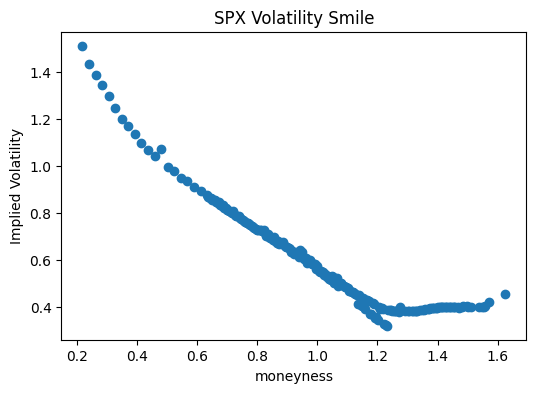

In [ ]:
df_plot = df[df.DTE == 56]

plt.figure(figsize=(6,4))
plt.scatter(df_plot['MONEYNESS'], df_plot['IV'])
plt.xlabel("moneyness")
plt.ylabel("Implied Volatility")
plt.title("SPX Volatility Smile")
plt.show()

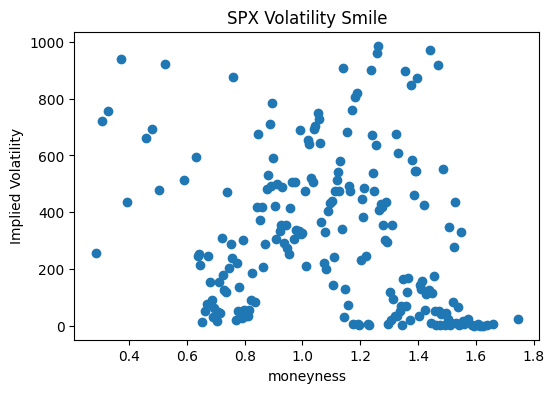

In [ ]:
df_plot = df[df.DTE == 56]

plt.figure(figsize=(6,4))
plt.scatter(df_plot['MONEYNESS'], df_plot['VOLUME'])
plt.xlabel("moneyness")
plt.ylabel("Implied Volatility")
plt.title("SPX Volatility Smile")
plt.show()